In [34]:
import numpy as np
import matplotlib.pyplot as plt


In [35]:
masks = np.load('trimmed_masks.npz')



In [36]:
masks

NpzFile 'trimmed_masks.npz' with keys: masks

In [37]:
all_masks = masks['masks']

In [38]:
all_masks.shape

(208, 276, 300, 1)

In [39]:
!wget https://github.com/Avanith12/Splean_Analysis/raw/refs/heads/main/trimmed_images.npz

--2026-03-06 11:58:44--  https://github.com/Avanith12/Splean_Analysis/raw/refs/heads/main/trimmed_images.npz
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Avanith12/Splean_Analysis/refs/heads/main/trimmed_images.npz [following]
--2026-03-06 11:58:45--  https://raw.githubusercontent.com/Avanith12/Splean_Analysis/refs/heads/main/trimmed_images.npz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 51667466 (49M) [application/octet-stream]
Saving to: ‘trimmed_images.npz.2’

trimmed_images.npz. 100%[===================>]  49.27M  93.7MB/s    in 0.5s    

2026-03-06 11:58:46 (93.7 MB/s) - ‘trimmed_ima

In [40]:
images = np.load('trimmed_images.npz')

In [41]:
all_images = images['images']

In [42]:
all_images.shape

(208, 276, 300, 3)

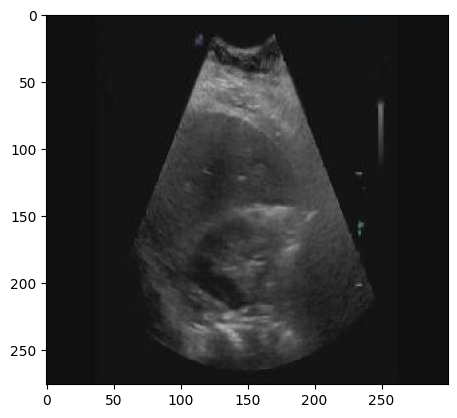

In [43]:
import matplotlib.pyplot as plt

plt.imshow(all_images[0])
plt.show()




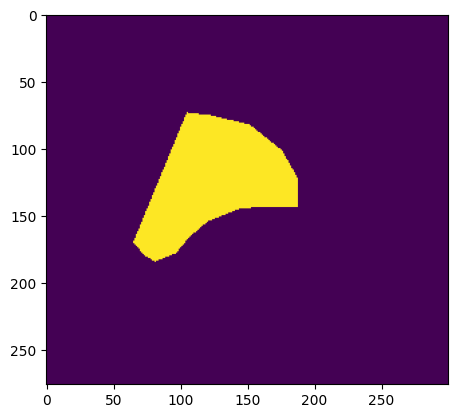

In [44]:
plt.imshow(all_masks[0])    

In [45]:
all_masks.shape


(208, 276, 300, 1)

In [46]:
x_train = all_images[0:170]
y_train = all_masks[0:170]




In [47]:
x_train.shape

(170, 276, 300, 3)

In [48]:
y_train.shape

(170, 276, 300, 1)

In [49]:
x_test = all_images[170:]
y_test = all_masks[170:]


In [50]:
x_test.shape


(38, 276, 300, 3)

In [51]:
y_test.shape

(38, 276, 300, 1)

In [52]:
x_train = np.pad(x_train, ((0,0),(22,22),(10,10),(0,0)))
y_train = np.pad(y_train, ((0,0),(22,22),(10,10),(0,0)))
x_test = np.pad(x_test, ((0,0),(22,22),(10,10),(0,0)))
y_test = np.pad(y_test, ((0,0),(22,22),(10,10),(0,0)))

In [53]:
x_train.shape
y_train.shape

(170, 320, 320, 1)

In [54]:
x_test.shape
y_test.shape

(38, 320, 320, 1)

In [55]:
from keras_unet.models import custom_unet

In [56]:
from keras_unet.utils import get_augmented

In [57]:
import inspect
print(inspect.signature(get_augmented))

(X_train, Y_train, X_val=None, Y_val=None, batch_size=32, seed=0, data_gen_args={'rotation_range': 10.0, 'height_shift_range': 0.02, 'shear_range': 5, 'horizontal_flip': True, 'vertical_flip': False, 'fill_mode': 'constant'})


In [58]:
batch_size = 8
train_gen, val_gen = get_augmented(x_train, y_train, X_val=x_test, Y_val=y_test, batch_size=batch_size, seed=42)
steps_per_epoch = len(x_train) // batch_size
validation_steps = max(1, len(x_test) // batch_size)

In [59]:
model = custom_unet(
    input_shape=(320, 320, 3)
)
model.compile(loss='binary_crossentropy')

In [60]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 320, 320,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 320, 320,  │        432 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 320,  │         64 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_5 │ (None, 320, 320,  │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 320, 320,  │      2,304 │ spatial_dropout2… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 320,  │         64 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 160, 160,  │      4,608 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        128 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_6 │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 160, 160,  │      9,216 │ spatial_dropout2… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        128 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 80, 80,    │     18,432 │ max_pooling2d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        256 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_7 │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 80, 80,    │     36,864 │ spatial_dropout2

 Total params: 1,945,521 (7.42 MB)

 Trainable params: 1,942,577 (7.41 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [61]:
!nvidia-smi

Fri Mar  6 11:58:50 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.230.02             Driver Version: 535.230.02   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off | 00000000:07:00.0 Off |                    0 |
| N/A   26C    P0              57W / 400W |  38865MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [62]:
def as_keras_gen(zip_gen):
    for x_batch, y_batch in zip_gen:
        yield x_batch, y_batch

In [63]:
history = model.fit(
    as_keras_gen(train_gen),
    steps_per_epoch=steps_per_epoch,
    epochs=60,
    validation_data=as_keras_gen(val_gen),
    validation_steps=validation_steps
)

Epoch 1/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 233ms/step - loss: 0.6776 - val_loss: 0.6783
Epoch 2/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - loss: 0.5763 - val_loss: 0.6651
Epoch 3/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - loss: 0.5126 - val_loss: 0.6262
Epoch 4/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 294ms/step - loss: 0.4482 - val_loss: 0.4510
Epoch 5/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - loss: 0.3707 - val_loss: 0.4627
Epoch 6/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step - loss: 0.3000 - val_loss: 3.6457
Epoch 7/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - loss: 0.2618 - val_loss: 0.3801
Epoch 8/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - loss: 0.2296 - val_loss: 0.7062
Epoch 9/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step - loss: 0.1928 - val_loss: 0.4240
Epoch 10/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - loss: 0.1634 - val_loss: 0.4948
Epoch 11/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 163ms/step - loss: 0.1424 - val_loss: 0.3998
Epoch 12/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/st

In [64]:
y_pred = model.predict(x_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step


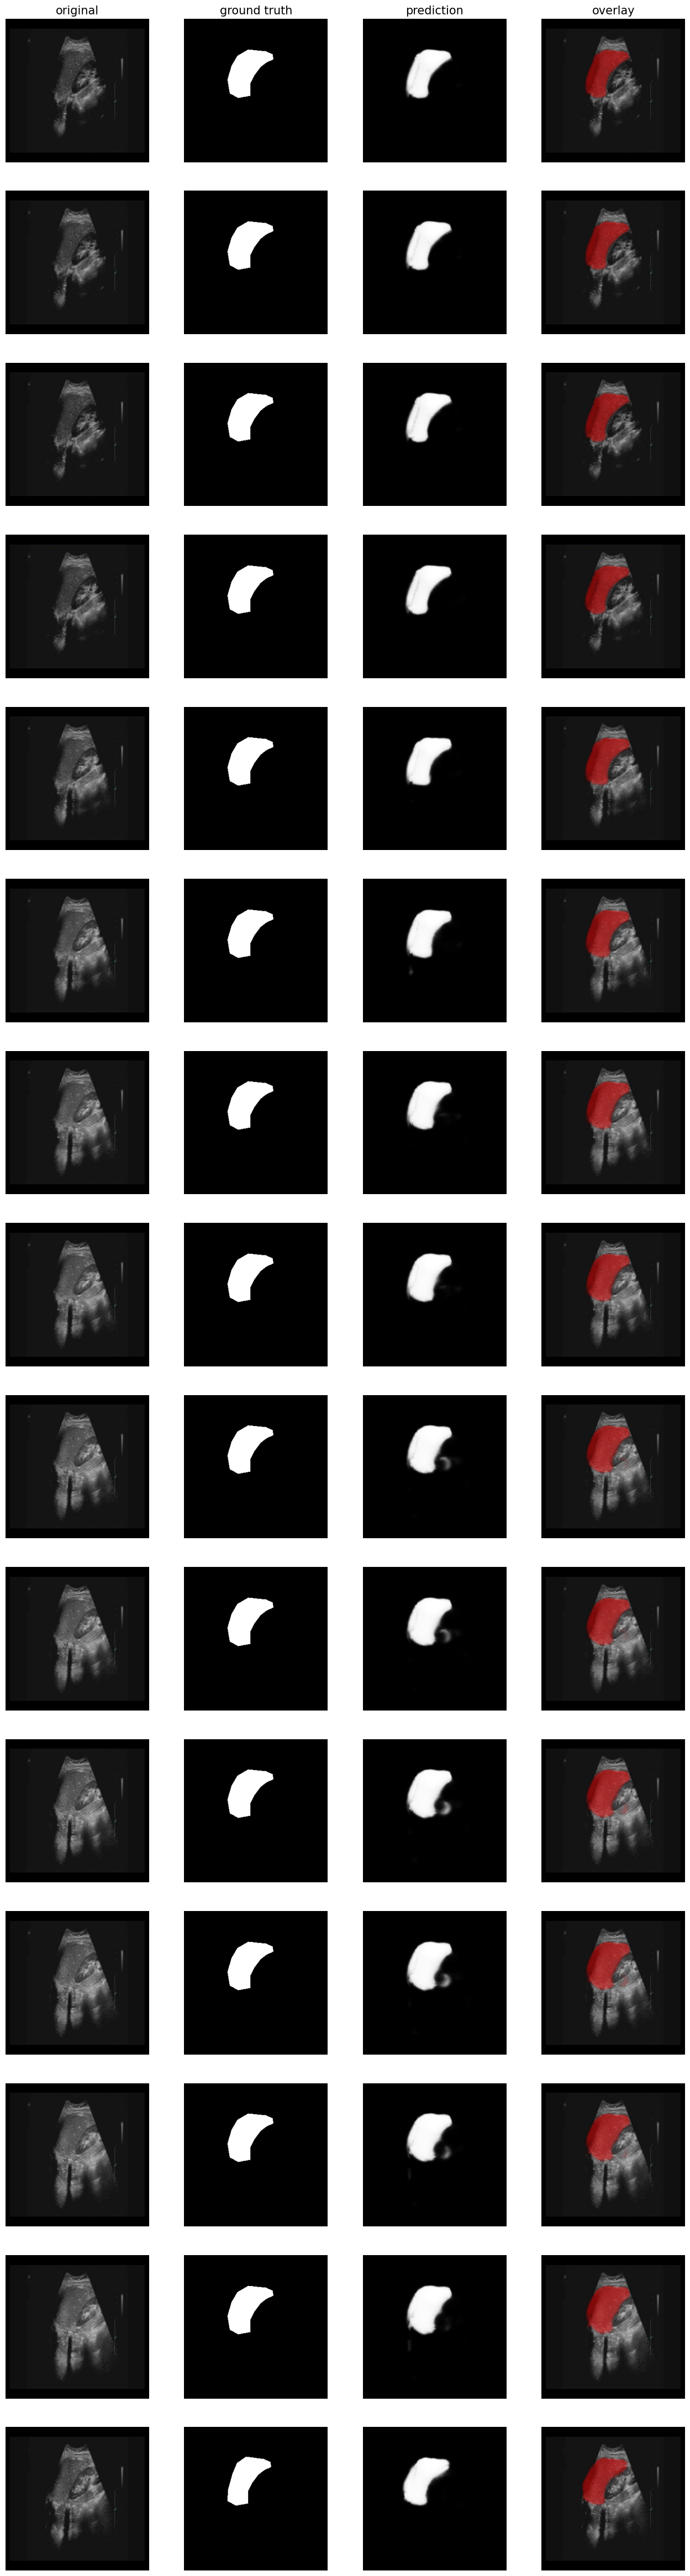

In [65]:
from keras_unet.utils import plot_imgs

plot_imgs(org_imgs=x_test, mask_imgs=y_test, pred_imgs=y_pred, nm_img_to_plot=15)